<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day21_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 21 Lab: Clustering

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

## Read in the data and display the first few rows.

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1Gg5-kQhQMFHCibZIWlw-DR0c119tEvmq')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Don’t do any data cleaning yet, except for mapping the Sex column to be 0 (female) and 1 (male).

In [ ]:
ord_map = {'female': 0, 'male': 1}
df['Sex'] = df['Sex'].map(ord_map)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


## Create a copy of the original data frame called cluster_df with the columns: 'Pclass', 'Sex', 'SibSp', 'Parch', 'Fare'

In [ ]:
cluster_df = df[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare']]
cluster_df.head()

,Pclass,Sex,SibSp,Parch,Fare
0,3,1,1,0,7.2500
1,1,0,1,0,71.2833
2,3,0,0,0,7.9250
3,1,0,1,0,53.1000
4,3,1,0,0,8.0500


## Normalize the data in preparation for clustering.

In [ ]:
# min-max normalization
mins = cluster_df.min(axis=0)
maxes = cluster_df.max(axis=0)
data_range = maxes - mins
cluster_df = (cluster_df - mins) / (data_range)
cluster_df.head()

,Pclass,Sex,SibSp,Parch,Fare
0,1.0,1.0,0.125,0.0,0.014151
1,0.0,0.0,0.125,0.0,0.139136
2,1.0,0.0,0.000,0.0,0.015469
3,0.0,0.0,0.125,0.0,0.103644
4,1.0,1.0,0.000,0.0,0.015713


## Cluster the data, varying K. Create a graph of K vs SSE

Text(0.5, 1.0, 'K vs SSE')

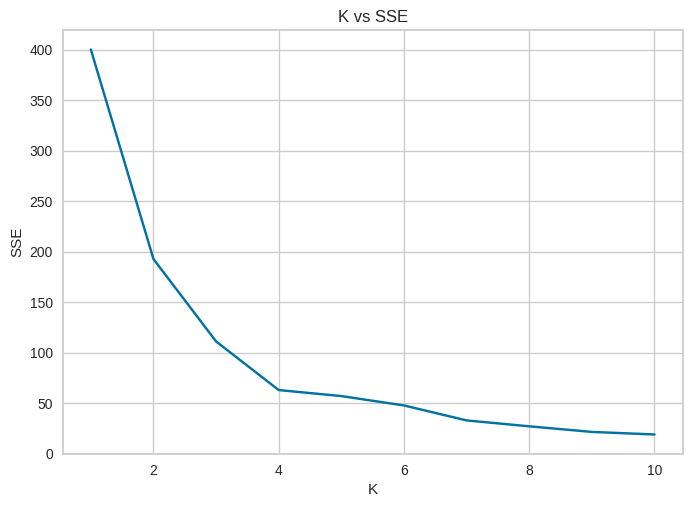

In [ ]:
sse_vals = []
k_vals = np.arange(1, 11)

for k in k_vals:
    model = KMeans(n_clusters=k, random_state=99)
    model.fit(cluster_df)
    sse_vals.append(model.inertia_)

plt.plot(k_vals, sse_vals)
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('K vs SSE')

## Make silhouette graphs for k=2 through 10 (i.e., 9 separate graphs).

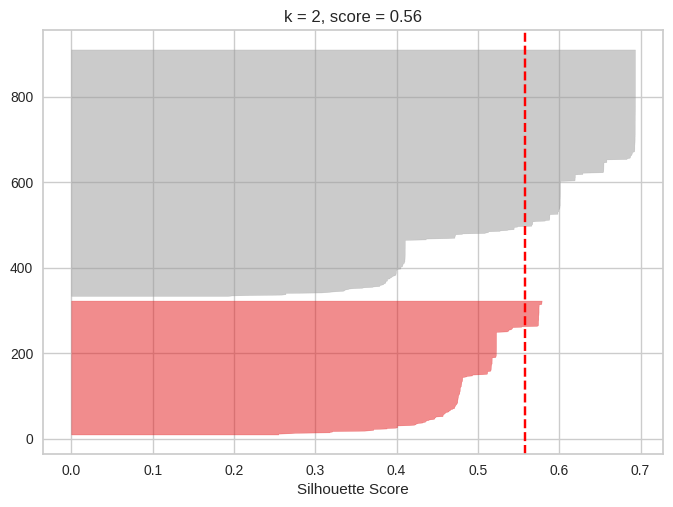

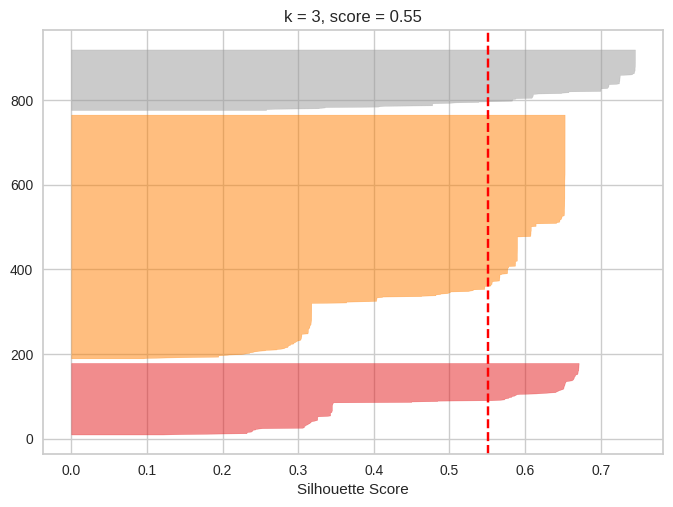

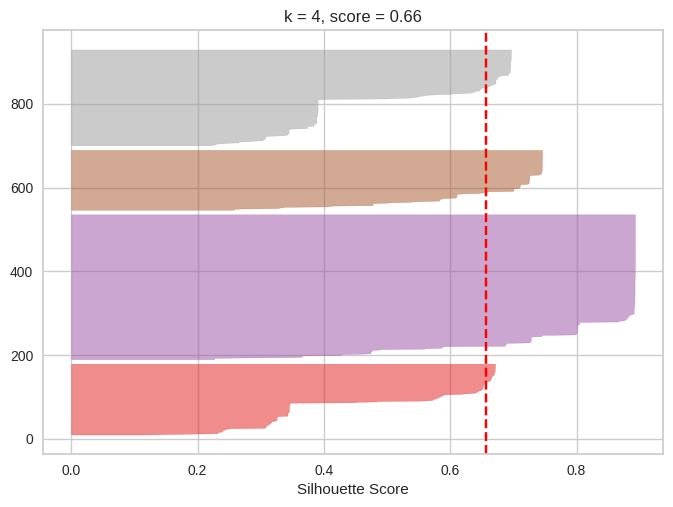

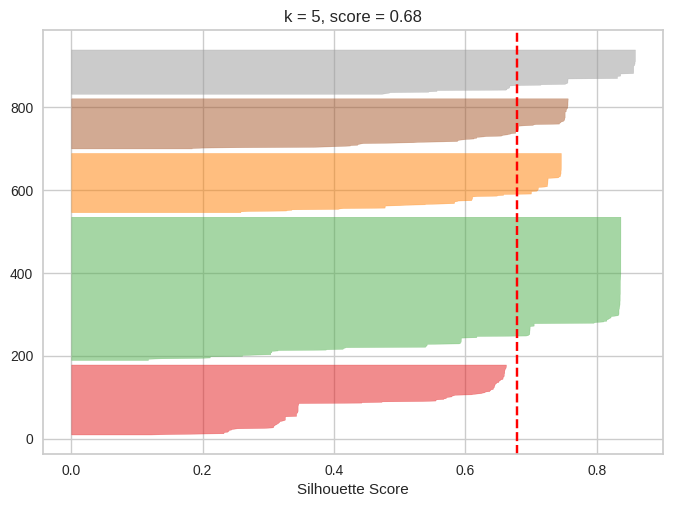

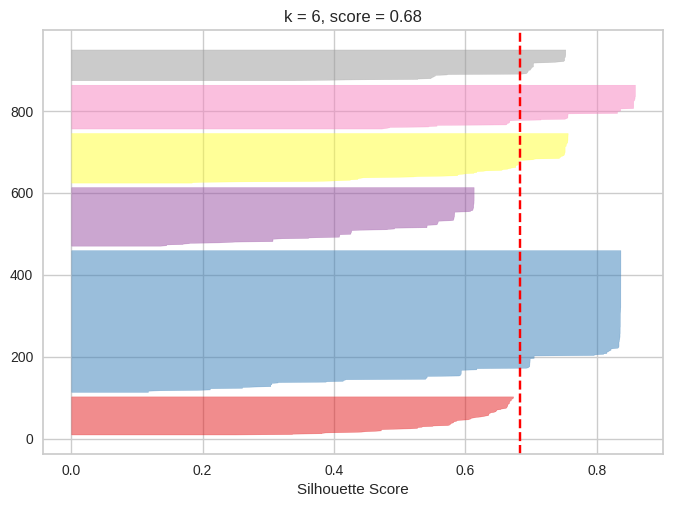

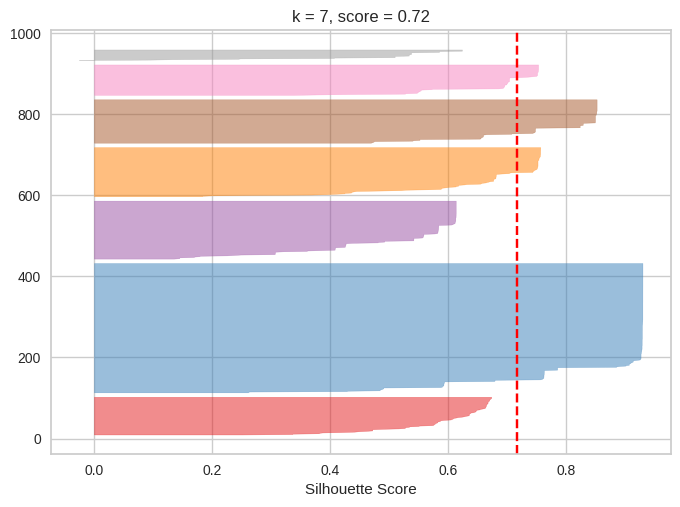

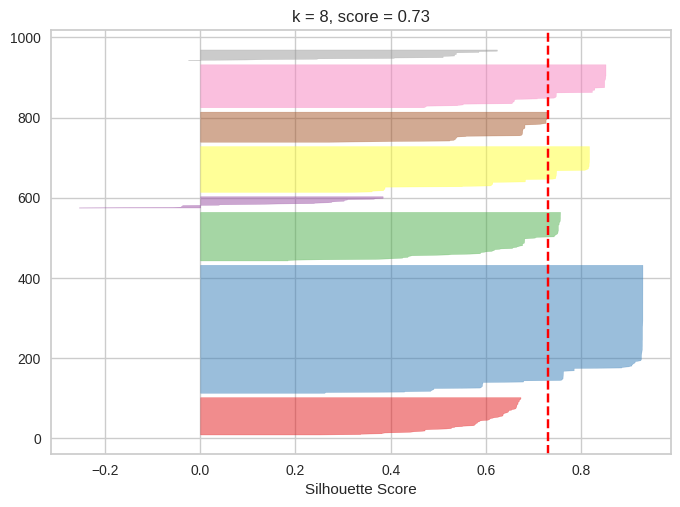

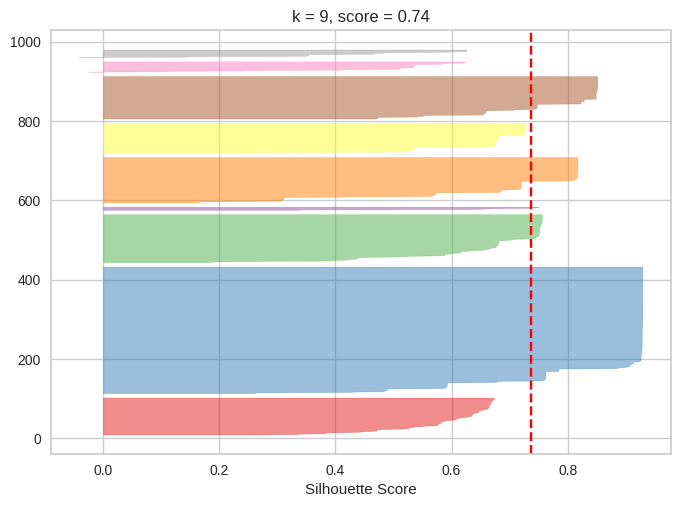

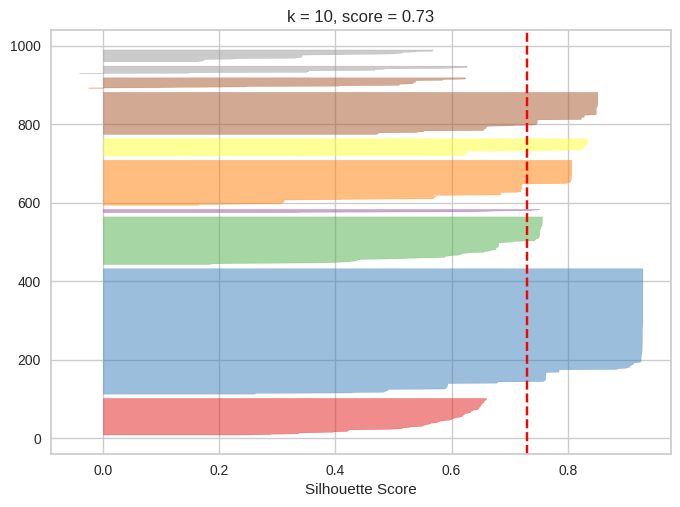

In [ ]:
for k in range(2, 11):
    fig, ax = plt.subplots()

    model = KMeans(n_clusters=k, n_init='auto', random_state=67)

    visualizer = SilhouetteVisualizer(model, ax=ax)
    visualizer.fit(cluster_df)

    ax.set_xlabel('Silhouette Score')
    ax.set_title(f'k = {k}, score = {visualizer.silhouette_score_:.2f}')


## Perform clustering on cluster_df with your selected K and save the predicted cluster labels as cluster_labels.
Add the cluster labels as a column in the original data frame, like this (I called mine KMgroup, for “K-means group”)


In [ ]:
model = KMeans(n_clusters=4, random_state=67)
model.fit(cluster_df)
cluster_labels = model.predict(cluster_df)
df['KMgroup'] = cluster_labels
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,KMgroup
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,1


## For your first cluster, cluster 0, make a mask and show the first 10 rows of data in that cluster. Use describe to show the descriptive statistics for this cluster. In a text cell, discuss: what do people have in common? Why did K-means put these people together?
Repeat with the second cluster, cluster 1.


In [ ]:
mask = df['KMgroup'] == 0
df[mask].head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,KMgroup
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.0,1,0,237736,30.0708,NaN,C,0
11,12,1,1,"Bonnell, Miss. Elizabeth",0,58.0,0,0,113783,26.5500,C103,S,0
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",0,55.0,0,0,248706,16.0000,NaN,S,0
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",0,NaN,1,0,PC 17569,146.5208,B78,C,0
41,42,0,2,"Turpin, Mrs. William John Robert (Dorothy Ann ...",0,27.0,1,0,11668,21.0000,NaN,S,0
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",0,3.0,1,2,SC/Paris 2123,41.5792,NaN,C,0
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",0,49.0,1,0,PC 17572,76.7292,D33,C,0
53,54,1,2,"Faunthorpe, Mrs. Lizzie (Elizabeth Anne Wilkin...",0,29.0,1,0,2926,26.0000,NaN,S,0


In [ ]:
df[mask].describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,KMgroup
count,170.000000,170.000000,170.000000,170.0,159.000000,170.000000,170.000000,170.000000,170.0
mean,457.541176,0.947059,1.447059,0.0,31.871069,0.523529,0.523529,68.503260,0.0
std,245.383075,0.224578,0.498658,0.0,13.555467,0.654551,0.778429,69.629969,0.0
min,2.000000,0.000000,1.000000,0.0,2.000000,0.000000,0.000000,10.500000,0.0
25%,291.250000,1.000000,1.000000,0.0,23.000000,0.000000,0.000000,24.482300,0.0
50%,439.500000,1.000000,1.000000,0.0,31.000000,0.000000,0.000000,49.502100,0.0
75%,649.500000,1.000000,2.000000,0.0,40.000000,1.000000,1.000000,85.743750,0.0
max,888.000000,1.000000,2.000000,0.0,63.000000,3.000000,3.000000,512.329200,0.0


In [ ]:
mask = df['KMgroup'] == 1
df[mask].head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,KMgroup
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,1
5,6,0,3,"Moran, Mr. James",1,NaN,0,0,330877,8.4583,NaN,Q,1
7,8,0,3,"Palsson, Master. Gosta Leonard",1,2.0,3,1,349909,21.0750,NaN,S,1
12,13,0,3,"Saundercock, Mr. William Henry",1,20.0,0,0,A/5. 2151,8.0500,NaN,S,1
13,14,0,3,"Andersson, Mr. Anders Johan",1,39.0,1,5,347082,31.2750,NaN,S,1
16,17,0,3,"Rice, Master. Eugene",1,2.0,4,1,382652,29.1250,NaN,Q,1
26,27,0,3,"Emir, Mr. Farred Chehab",1,NaN,0,0,2631,7.2250,NaN,C,1
29,30,0,3,"Todoroff, Mr. Lalio",1,NaN,0,0,349216,7.8958,NaN,S,1
36,37,1,3,"Mamee, Mr. Hanna",1,NaN,0,0,2677,7.2292,NaN,C,1


In [ ]:
df[mask].describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,KMgroup
count,347.000000,347.000000,347.0,347.0,253.000000,347.000000,347.000000,347.000000,347.0
mean,455.515850,0.135447,3.0,1.0,26.507589,0.498559,0.224784,12.661633,1.0
std,261.921251,0.342694,0.0,0.0,12.159514,1.288846,0.623404,11.681696,0.0
min,1.000000,0.000000,3.0,1.0,0.420000,0.000000,0.000000,0.000000,1.0
25%,209.500000,0.000000,3.0,1.0,20.000000,0.000000,0.000000,7.750000,1.0
50%,466.000000,0.000000,3.0,1.0,25.000000,0.000000,0.000000,7.925000,1.0
75%,687.500000,0.000000,3.0,1.0,33.000000,0.000000,0.000000,10.008300,1.0
max,891.000000,1.000000,3.0,1.0,74.000000,8.000000,5.000000,69.550000,1.0


## Let’s fill in the NaN values in the age column. Rather than dropping them or filling them all in with the average age of every passenger on the ship, let’s find more representative average ages by filling in the NaN values based on the average age within each cluster.


In [ ]:
for k in range(4):
    mask = df['KMgroup'] == k
    mean_age = df.loc[mask, 'Age'].mean()
    print(mean_age)
    df.loc[mask, 'Age'] = df.loc[mask, 'Age'].fillna(mean_age)

31.871069182389938
26.507588932806325
21.75
36.06375


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  KMgroup      891 non-null    int32  
dtypes: float64(2), int32(1), int64(6), object(4)
memory usage: 87.1+ KB
